In [33]:
# ============================================================
# 🌊 TSUNAMI RISK ANALYSIS
# KMEANS + DBSCAN
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
from IPython.display import display, HTML

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

sns.set_style("darkgrid")

In [34]:
# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../data/raw/earthquake_data_tsunami.csv")

display(df.head())
print(df.info())

print("Duplicati:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.5 KB
None
Duplicati: 0

Missing values:
magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64


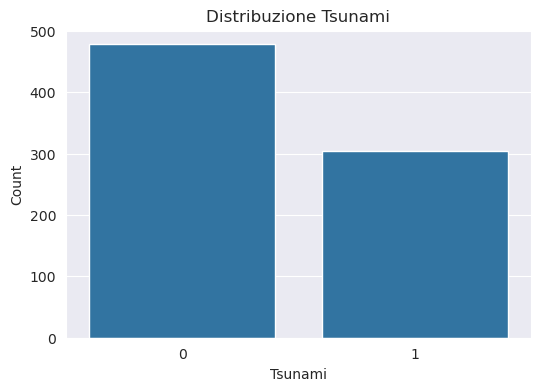

Tsunami rate globale: 38.87%


In [35]:
# ============================================================
# 2. BASIC TARGET ANALYSIS
# ============================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="tsunami")
plt.title("Distribuzione Tsunami")
plt.xlabel("Tsunami")
plt.ylabel("Count")
plt.show()

tsunami_rate = df["tsunami"].mean() * 100
print(f"Tsunami rate globale: {tsunami_rate:.2f}%")

In [36]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

df["dist_equatore"] = abs(df["latitude"])
df["shallow_quake"] = (df["depth"] <= 70).astype(int)
df["strong_quake"] = (df["magnitude"] >= 7).astype(int)
df["high_intensity"] = ((df["cdi"] >= 6) | (df["mmi"] >= 6)).astype(int)

df["risk_score"] = (
    0.35 * df["magnitude"] +
    0.25 * df["mmi"] +
    0.20 * df["cdi"] +
    0.15 * np.log1p(df["sig"]) +
    0.05 * df["shallow_quake"]
)

df["risk_score_norm"] = (
    df["risk_score"] - df["risk_score"].min()
) / (
    df["risk_score"].max() - df["risk_score"].min()
)

display(df[[
    "magnitude", "depth", "cdi", "mmi", "sig",
    "dist_equatore", "shallow_quake",
    "strong_quake", "high_intensity",
    "risk_score_norm", "tsunami"
]].head())

,magnitude,depth,cdi,mmi,sig,dist_equatore,shallow_quake,strong_quake,high_intensity,risk_score_norm,tsunami
0,7.0,14.000,8,7,768,9.7963,1,1,1,0.697939,1
1,6.9,25.000,4,4,735,4.9559,1,0,0,0.339607,0
2,7.0,579.000,3,3,755,20.0508,0,1,0,0.235821,1
3,7.3,37.000,5,5,833,19.2918,1,1,0,0.476663,1
4,6.6,624.464,0,2,670,25.5948,0,0,0,0.008902,1


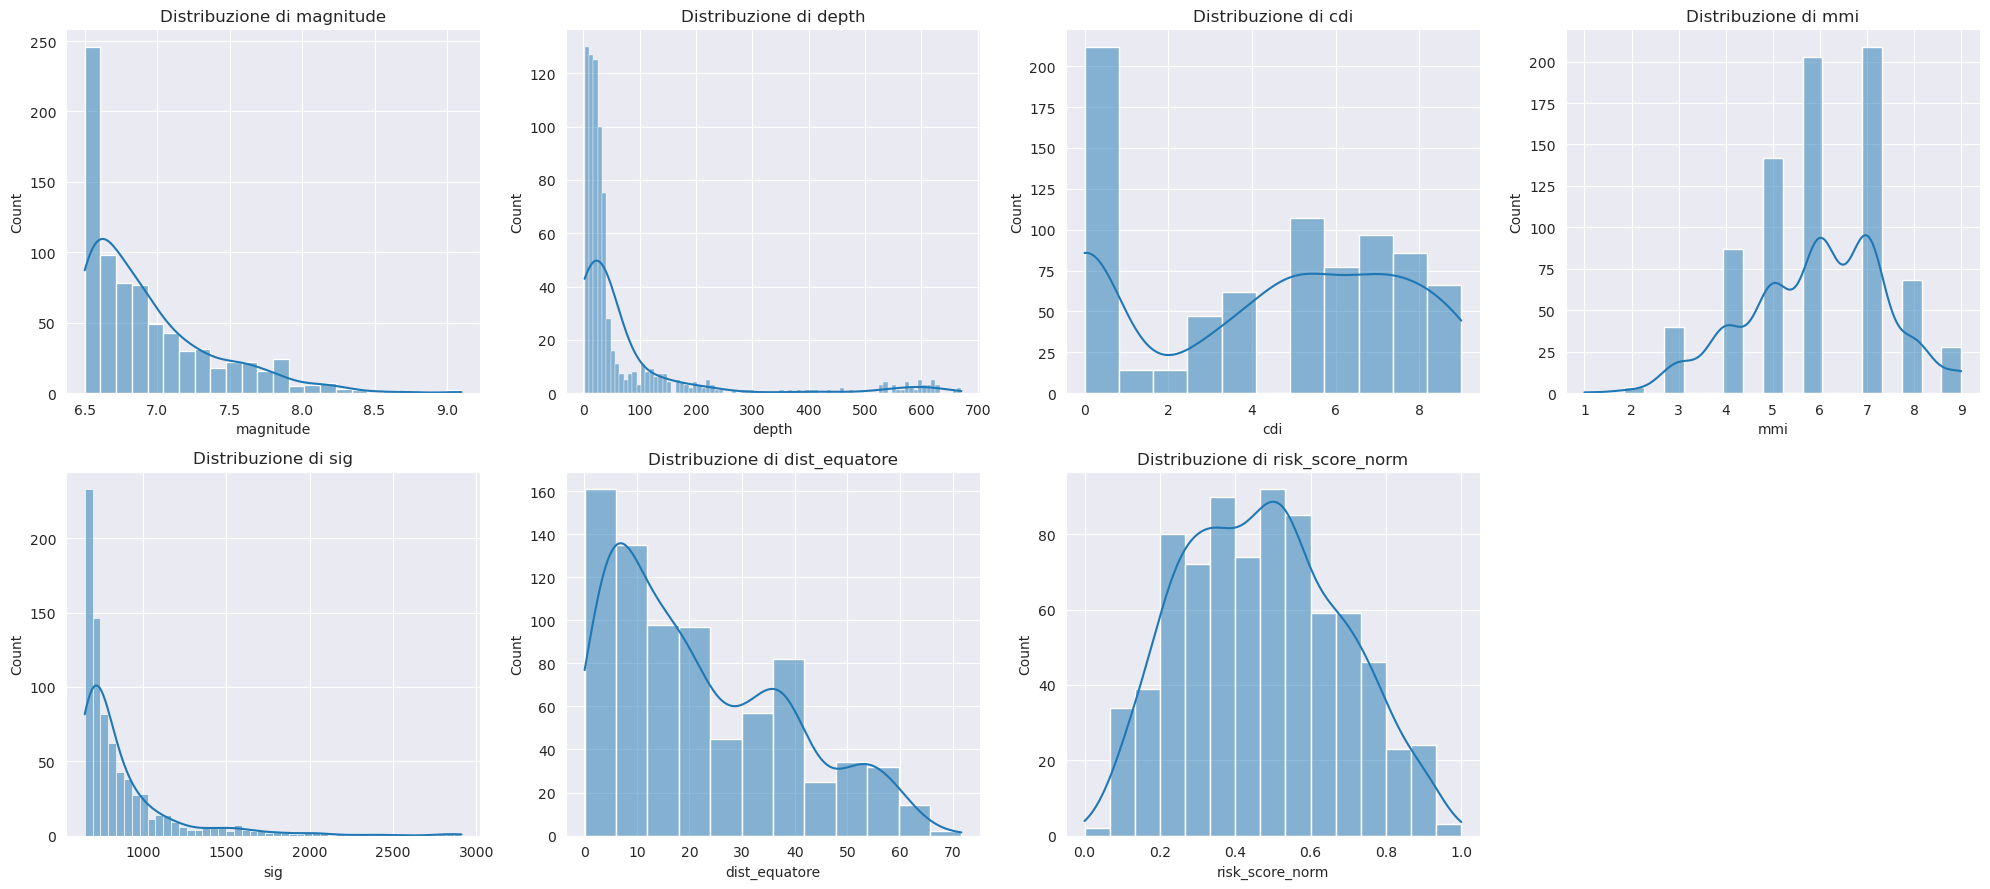

In [37]:
# ============================================================
# 4. EDA GRAFICI BASE
# ============================================================

features_to_plot = [
    "magnitude", "depth", "cdi", "mmi",
    "sig", "dist_equatore", "risk_score_norm"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()

for i, col in enumerate(features_to_plot):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribuzione di {col}")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

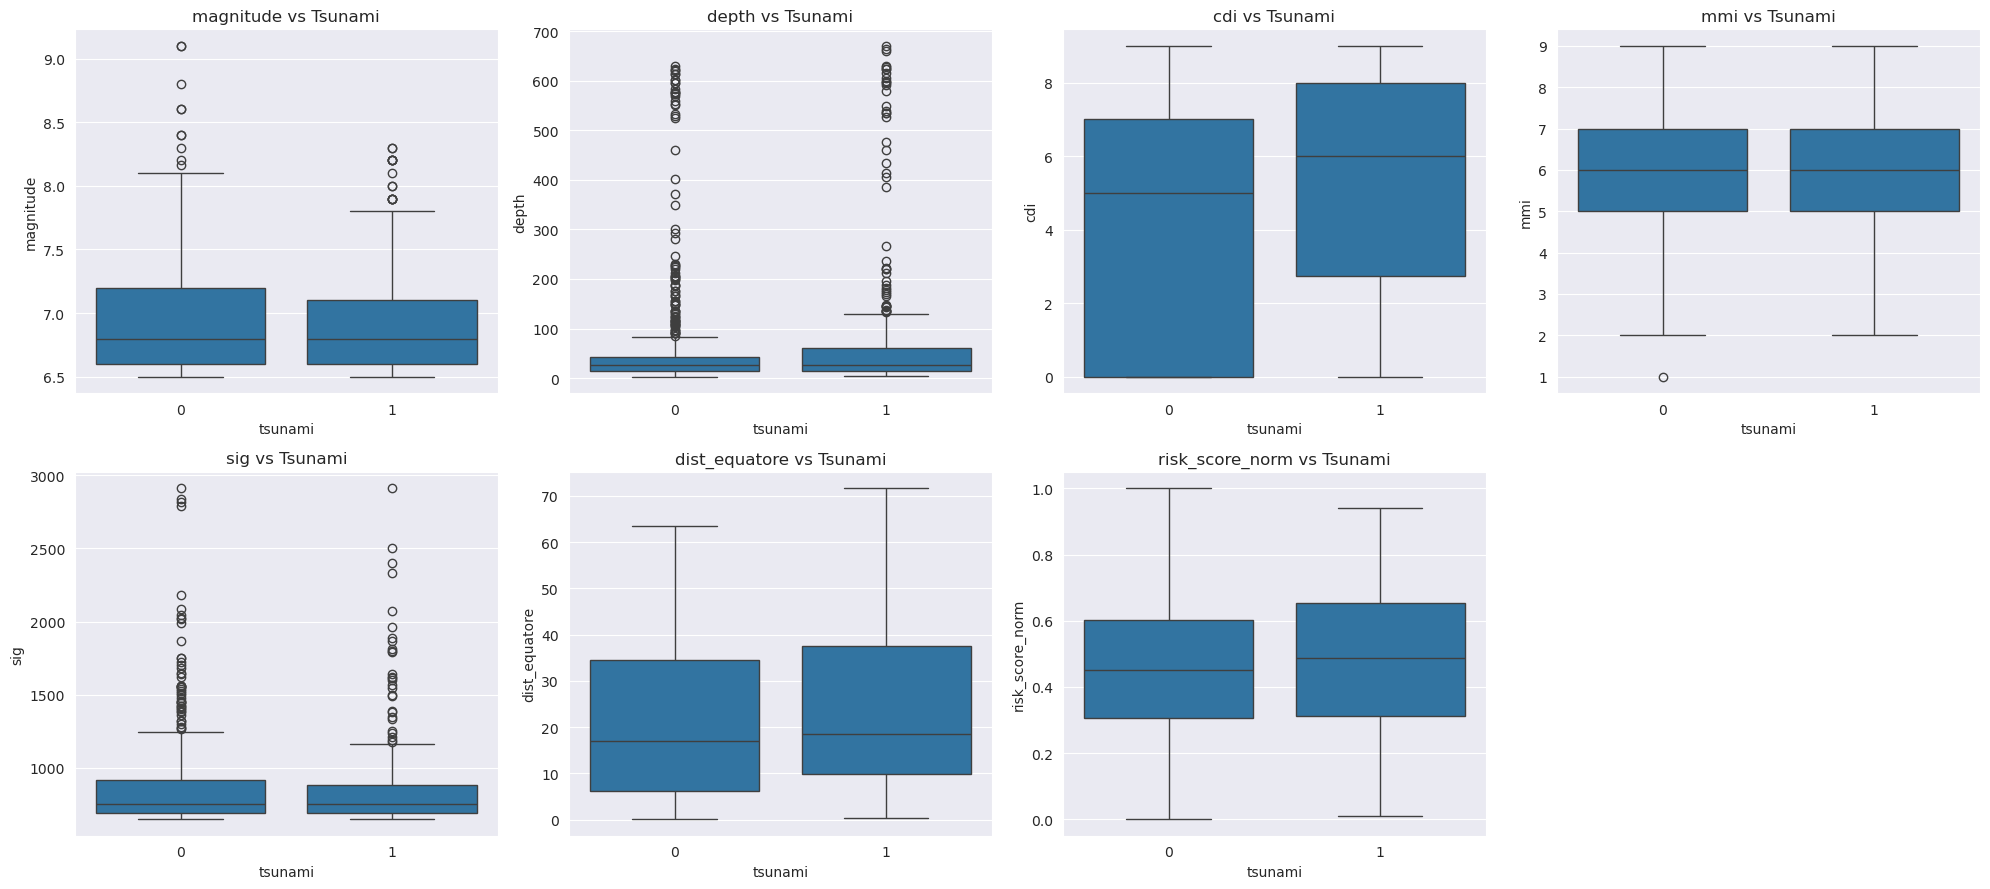

In [38]:
# ============================================================
# 5. FEATURE VS TSUNAMI
# ============================================================

features_to_compare = [
    "magnitude", "depth", "cdi", "mmi",
    "sig", "dist_equatore", "risk_score_norm"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()

for i, col in enumerate(features_to_compare):
    sns.boxplot(data=df, x="tsunami", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Tsunami")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

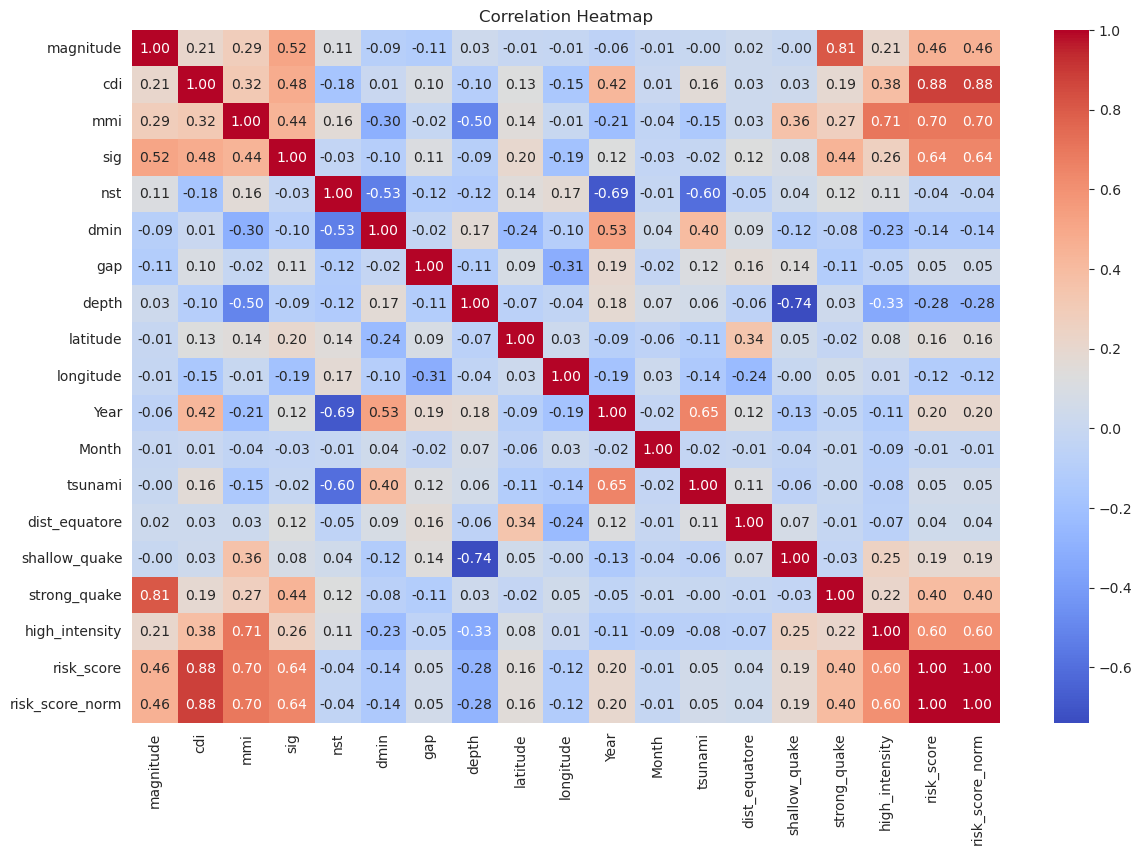

In [39]:
# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [40]:
# ============================================================
# 7. MAPPA BASE TSUNAMI / NO TSUNAMI
# ============================================================

df_map = df.copy()

df_map["tsunami_text"] = df_map["tsunami"].map({
    0: "No Tsunami",
    1: "Tsunami"
})

df_map["hover_text"] = df_map.apply(
    lambda row:
        f"<b>Earthquake</b><br>"
        f"Year: {row['Year']}<br>"
        f"Month: {row['Month']}<br>"
        f"Magnitude: {row['magnitude']}<br>"
        f"Depth: {row['depth']} km<br>"
        f"CDI: {row['cdi']}<br>"
        f"MMI: {row['mmi']}<br>"
        f"Tsunami: {row['tsunami_text']}",
    axis=1
)

fig = go.Figure()

for value, color, name, size in [
    (0, "green", "No Tsunami", 5),
    (1, "red", "Tsunami", 7)
]:
    data = df_map[df_map["tsunami"] == value]

    fig.add_trace(go.Scattergeo(
        lat=data["latitude"],
        lon=data["longitude"],
        mode="markers",
        text=data["hover_text"],
        hoverinfo="text",
        name=name,
        marker=dict(
            color=color,
            size=size,
            opacity=0.75,
            line=dict(width=0.4, color="white")
        )
    ))

fig.update_geos(
    projection_type="orthographic",
    landcolor="lightgray",
    oceancolor="lightblue",
    showocean=True,
    showland=True,
    showcountries=True,
    countrycolor="white"
)

fig.update_layout(
    title="🌍 Global Earthquake & Tsunami Distribution",
    height=650
)

display(HTML(fig.to_html(include_plotlyjs="cdn")))

In [41]:
# ============================================================
# 8. PREPROCESSING KMEANS
# ============================================================

kmeans_features = [
    "magnitude",
    "cdi",
    "mmi",
    "sig",
    "depth",
    "latitude",
    "longitude",
    "dist_equatore",
    "shallow_quake",
    "strong_quake",
    "high_intensity"
]

X_km = df[kmeans_features].copy()

scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

,K,Inertia,Silhouette
0,2,7006.407482,0.202825
1,3,5824.218130,0.226041
2,4,5131.165672,0.218976
3,5,4632.231914,0.225013
4,6,4241.845966,0.217479
5,7,3966.597572,0.220830
6,8,3790.289072,0.199329
7,9,3559.490162,0.216904
8,10,3412.419875,0.236758
9,11,3256.543032,0.233672


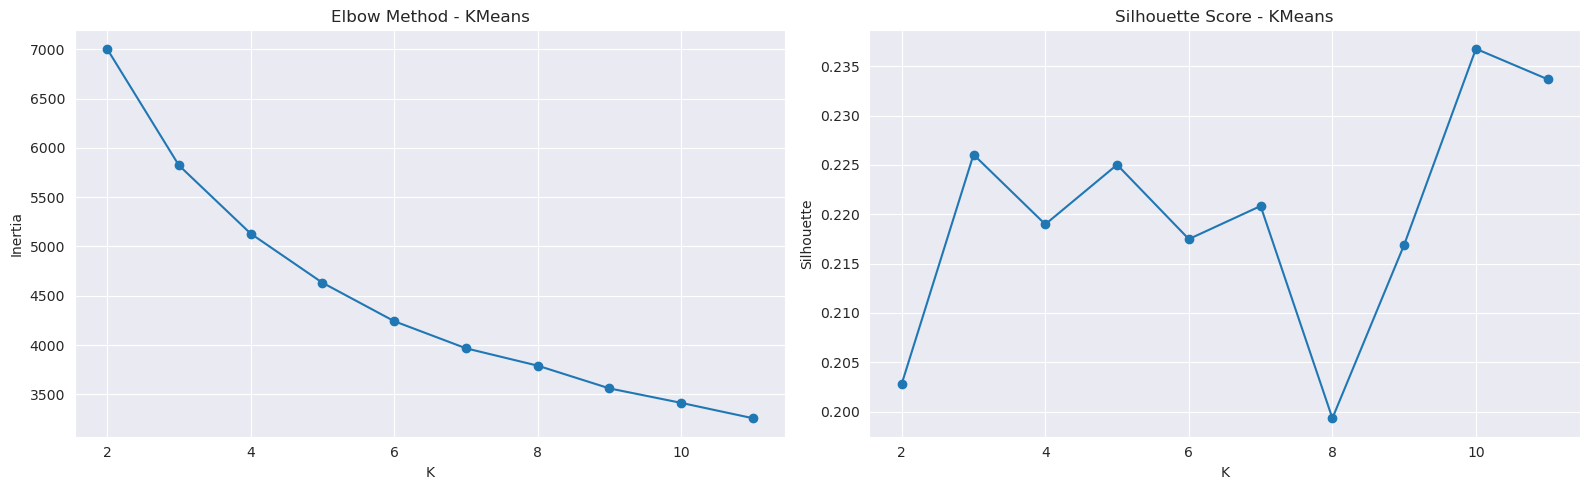

In [42]:
# ============================================================
# 9. KMEANS - ELBOW + SILHOUETTE
# ============================================================

inertias = []
silhouettes = []

K_range = range(2, 12)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_km_scaled)

    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_km_scaled, labels))

k_scores = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

display(k_scores)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, marker="o")
axes[0].set_title("Elbow Method - KMeans")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

axes[1].plot(K_range, silhouettes, marker="o")
axes[1].set_title("Silhouette Score - KMeans")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# 10. KMEANS FINALE
# Scelta ragionata: K=6
# ============================================================

kmeans_final = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = kmeans_final.fit_predict(X_km_scaled)

print(df["kmeans_cluster"].value_counts().sort_index())

kmeans_cluster
0    156
1    232
2    159
3     58
4     68
5    109
Name: count, dtype: int64


In [44]:
# ============================================================
# 11. ANALISI KMEANS
# ============================================================

kmeans_summary = df.groupby("kmeans_cluster").agg(
    count=("tsunami", "count"),
    tsunami_rate=("tsunami", "mean"),
    avg_magnitude=("magnitude", "mean"),
    avg_depth=("depth", "mean"),
    avg_cdi=("cdi", "mean"),
    avg_mmi=("mmi", "mean"),
    avg_sig=("sig", "mean"),
    avg_risk_score=("risk_score_norm", "mean"),
    avg_latitude=("latitude", "mean"),
    avg_longitude=("longitude", "mean")
)

kmeans_summary["tsunami_rate"] *= 100

display(kmeans_summary.sort_values("tsunami_rate", ascending=False))

,count,tsunami_rate,avg_magnitude,avg_depth,avg_cdi,avg_mmi,avg_sig,avg_risk_score,avg_latitude,avg_longitude
kmeans_cluster,,,,,,,,,,
2,159,46.540881,6.733333,47.308371,2.257862,4.559748,722.710692,0.276465,-0.170498,56.097172
3,58,44.827586,6.970690,520.324190,3.051724,3.465517,770.482759,0.262376,-2.746909,26.403936
4,68,44.117647,7.501471,37.346338,8.308824,7.735294,1691.250000,0.817078,18.768554,-30.395829
1,232,37.931034,6.669828,35.809957,4.448276,6.245690,744.913793,0.466688,-6.916157,56.857150
0,156,36.538462,7.408718,46.044423,4.576923,6.576923,902.166667,0.555374,-8.235411,84.085324
5,109,26.605505,6.787156,33.114101,4.972477,6.761468,846.449541,0.532876,41.892062,59.158371


In [45]:
# ============================================================
# 12. CATEGORIA RISCHIO KMEANS
# ============================================================

def assign_risk_category(rate):
    if rate >= 60:
        return "HIGH RISK 🔴"
    elif rate >= 40:
        return "MEDIUM RISK 🟡"
    elif rate <= 20:
        return "LOW RISK 🟢"
    else:
        return "NEUTRAL RISK ⚪"


kmeans_risk_map = kmeans_summary["tsunami_rate"].to_dict()

df["kmeans_risk"] = df["kmeans_cluster"].map(
    lambda x: assign_risk_category(kmeans_risk_map[x])
)

display(
    df.groupby("kmeans_risk")["tsunami"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

,count,mean
kmeans_risk,,
MEDIUM RISK 🟡,285,0.456140
NEUTRAL RISK ⚪,497,0.350101


In [46]:
# ============================================================
# 13. PCA KMEANS
# ============================================================

pca = PCA(n_components=2)
X_km_pca = pca.fit_transform(X_km_scaled)

df["PCA1"] = X_km_pca[:, 0]
df["PCA2"] = X_km_pca[:, 1]

print("Explained variance PCA:")
print(pca.explained_variance_ratio_)

Explained variance PCA:
[0.28659965 0.18040474]


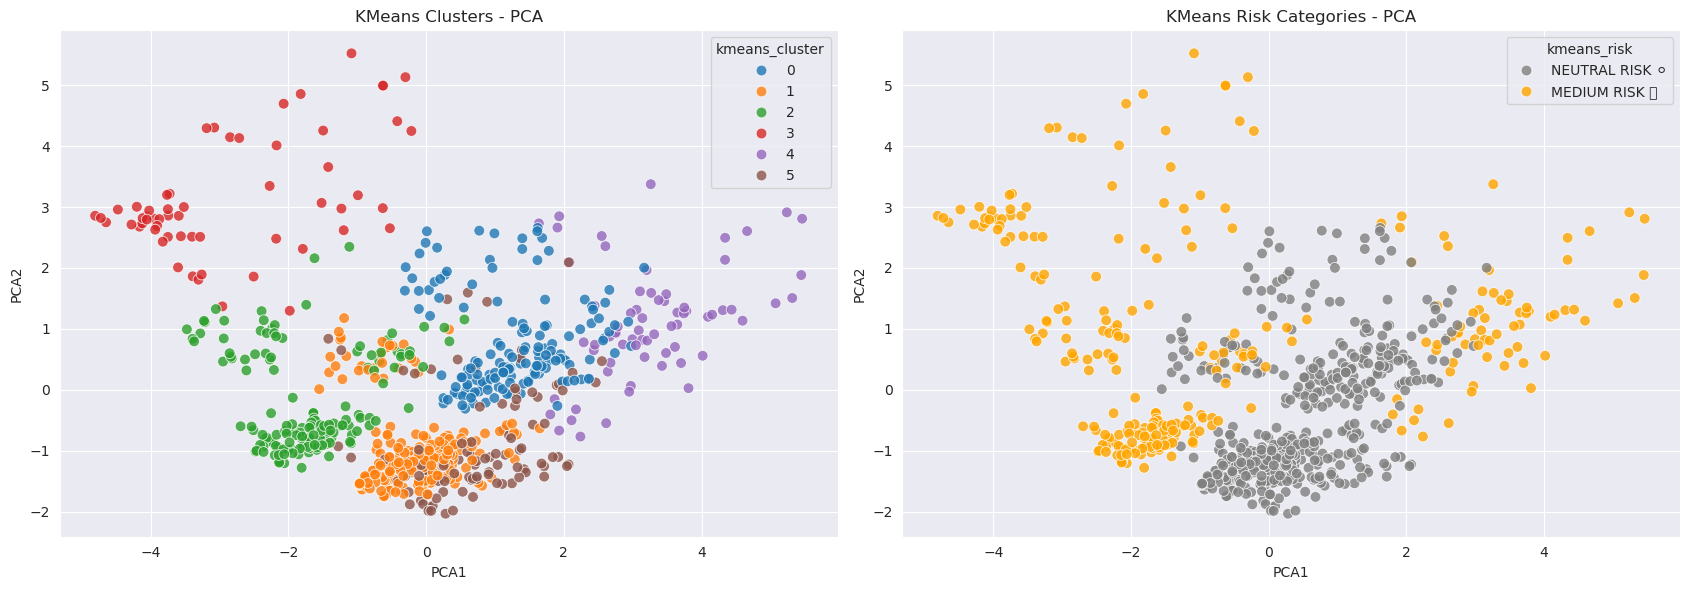

In [47]:
# ============================================================
# 14. GRAFICI PCA KMEANS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    alpha=0.8,
    ax=axes[0]
)

axes[0].set_title("KMeans Clusters - PCA")
axes[0].grid(True)

risk_palette = {
    "HIGH RISK 🔴": "red",
    "MEDIUM RISK 🟡": "orange",
    "LOW RISK 🟢": "green",
    "NEUTRAL RISK ⚪": "gray"
}

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="kmeans_risk",
    palette=risk_palette,
    s=60,
    alpha=0.8,
    ax=axes[1]
)

axes[1].set_title("KMeans Risk Categories - PCA")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# 15. MAPPA KMEANS
# ============================================================

def create_kmeans_world_map(df):

    colors = {
        "HIGH RISK 🔴": "red",
        "MEDIUM RISK 🟡": "orange",
        "LOW RISK 🟢": "green",
        "NEUTRAL RISK ⚪": "gray"
    }

    df_map = df.copy()

    df_map["hover_text"] = df_map.apply(
        lambda row:
            f"<b>Earthquake</b><br>"
            f"Year: {row['Year']}<br>"
            f"Month: {row['Month']}<br>"
            f"Magnitude: {row['magnitude']}<br>"
            f"Depth: {row['depth']} km<br>"
            f"CDI: {row['cdi']}<br>"
            f"MMI: {row['mmi']}<br>"
            f"Tsunami: {'YES' if row['tsunami'] == 1 else 'NO'}<br>"
            f"KMeans Cluster: {row['kmeans_cluster']}<br>"
            f"Risk: {row['kmeans_risk']}",
        axis=1
    )

    fig = go.Figure()

    for risk, color in colors.items():
        data = df_map[df_map["kmeans_risk"] == risk]

        if len(data) > 0:
            fig.add_trace(go.Scattergeo(
                lat=data["latitude"],
                lon=data["longitude"],
                mode="markers",
                name=risk,
                text=data["hover_text"],
                hoverinfo="text",
                marker=dict(
                    color=color,
                    size=7,
                    opacity=0.8,
                    line=dict(width=0.4, color="white")
                )
            ))

    fig.update_geos(
        projection_type="orthographic",
        landcolor="lightgray",
        oceancolor="lightblue",
        showocean=True,
        showland=True,
        showcountries=True,
        countrycolor="white"
    )

    fig.update_layout(
        title="🌍 KMeans Tsunami Risk Map",
        height=650,
        legend_title="Risk Level"
    )

    return fig


fig = create_kmeans_world_map(df)
display(HTML(fig.to_html(include_plotlyjs="cdn")))

In [49]:
# ============================================================
# 16. DBSCAN - FEATURE SELECTION
# DBSCAN usato per ANOMALY DETECTION
# ============================================================

dbscan_features = [
    "latitude",
    "longitude",
    "magnitude",
    "depth"
]

X_db = df[dbscan_features].copy()

scaler_db = StandardScaler()
X_db_scaled = scaler_db.fit_transform(X_db)

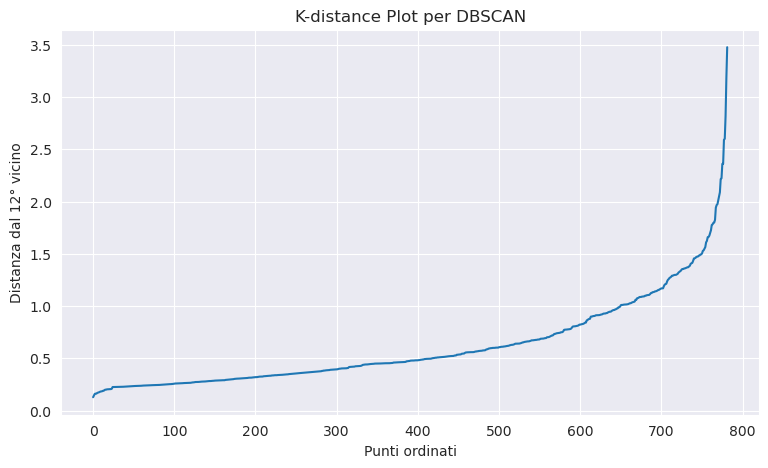

In [50]:
# ============================================================
# 17. DBSCAN - K-DISTANCE PLOT
# ============================================================

min_samples = 12

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_db_scaled)

distances, indices = neighbors_fit.kneighbors(X_db_scaled)
distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(9, 5))
plt.plot(distances)
plt.title("K-distance Plot per DBSCAN")
plt.xlabel("Punti ordinati")
plt.ylabel(f"Distanza dal {min_samples}° vicino")
plt.grid(True)
plt.show()

In [51]:
# ============================================================
# 18. DBSCAN AUTO-TUNING
# ============================================================

eps_values = np.arange(0.3, 3.1, 0.1)
min_samples_values = [5, 8, 10, 12, 15]

results = []

for eps in eps_values:
    for min_s in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_s
        )

        labels = dbscan.fit_predict(X_db_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)

        if n_clusters >= 2:
            mask = labels != -1

            if len(set(labels[mask])) >= 2:
                sil = silhouette_score(X_db_scaled[mask], labels[mask])
            else:
                sil = np.nan
        else:
            sil = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_s,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil
        })

dbscan_results = pd.DataFrame(results)

display(
    dbscan_results
    .sort_values("silhouette", ascending=False)
    .head(20)
)

,eps,min_samples,n_clusters,noise_ratio,silhouette
4,0.3,15,4,0.710997,0.673462
3,0.3,12,4,0.629156,0.617218
2,0.3,10,6,0.579284,0.517797
38,1.0,12,2,0.080563,0.512339
9,0.4,15,5,0.523018,0.496603
31,0.9,8,3,0.088235,0.484649
1,0.3,8,8,0.516624,0.482101
37,1.0,10,3,0.054987,0.477725
42,1.1,10,3,0.040921,0.475993
43,1.1,12,3,0.040921,0.475993


In [52]:
# ============================================================
# 19. SCELTA AUTOMATICA DBSCAN
# ============================================================

valid_dbscan = dbscan_results[
    (dbscan_results["n_clusters"] >= 2) &
    (dbscan_results["n_clusters"] <= 8) &
    (dbscan_results["noise_ratio"] <= 0.40) &
    (dbscan_results["silhouette"].notna())
].copy()

best_dbscan_row = valid_dbscan.sort_values(
    ["silhouette", "noise_ratio"],
    ascending=[False, True]
).iloc[0]

best_eps = best_dbscan_row["eps"]
best_min_samples = int(best_dbscan_row["min_samples"])

print("Best DBSCAN parameters:")
display(best_dbscan_row)

Best DBSCAN parameters:


eps             1.000000
min_samples    12.000000
n_clusters      2.000000
noise_ratio     0.080563
silhouette      0.512339
Name: 38, dtype: float64

In [53]:
# ============================================================
# 20. DBSCAN FINALE
# ============================================================

dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

df["dbscan_cluster"] = dbscan_final.fit_predict(X_db_scaled)

print(df["dbscan_cluster"].value_counts().sort_index())

dbscan_cluster
-1     63
 0    707
 1     12
Name: count, dtype: int64


In [54]:
# ============================================================
# 22. DBSCAN OUTLIER ANALYSIS
# ============================================================

outliers = df[df["dbscan_cluster"] == -1]

print("Numero outlier:", len(outliers))
print(f"Percentuale outlier: {len(outliers) / len(df) * 100:.2f}%")
print(f"Tsunami rate outlier: {outliers['tsunami'].mean() * 100:.2f}%")

display(
    outliers[[
        "Year", "Month", "magnitude", "depth",
        "latitude", "longitude", "tsunami",
        "risk_score_norm"
    ]]
    .sort_values("risk_score_norm", ascending=False)
    .head(20)
)

Numero outlier: 63
Percentuale outlier: 8.06%
Tsunami rate outlier: 49.21%


,Year,Month,magnitude,depth,latitude,longitude,tsunami,risk_score_norm
476,2011,3,9.1,29.00,38.2970,142.3730,0,1.000000
517,2010,2,8.8,22.90,-36.1220,-72.8980,0,0.928208
730,2002,11,7.9,4.20,63.5141,-147.4530,0,0.909219
441,2012,4,8.6,20.00,2.3270,93.0630,0,0.902144
74,2021,3,8.1,28.93,-29.7466,-177.2240,1,0.895539
198,2017,9,8.2,47.39,15.0222,-93.8993,1,0.882483
93,2020,7,7.8,28.00,55.1079,-158.4770,1,0.818463
60,2021,7,8.2,35.00,55.3154,-157.8290,1,0.808986
84,2020,10,7.6,28.37,54.6620,-159.6750,1,0.804305
424,2012,10,7.8,14.00,52.7880,-132.1010,0,0.788302


In [55]:
# ============================================================
# 23. CATEGORIA DBSCAN
# ============================================================

dbscan_risk_map = dbscan_summary["tsunami_rate"].to_dict()

df["dbscan_risk"] = df["dbscan_cluster"].map(
    lambda x: "OUTLIER ⚫" if x == -1 else assign_risk_category(dbscan_risk_map[x])
)

display(
    df.groupby("dbscan_risk")["tsunami"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

,count,mean
dbscan_risk,,
OUTLIER ⚫,63,0.492063
NEUTRAL RISK ⚪,719,0.379694


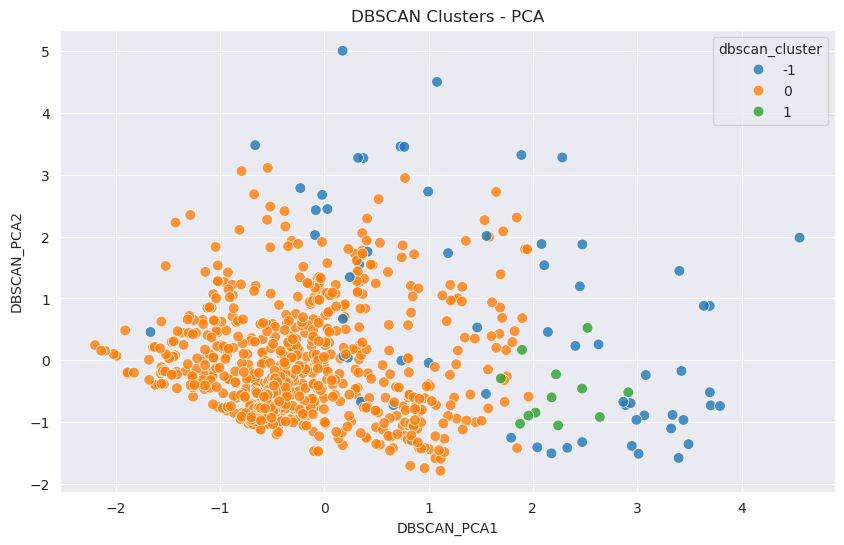

In [56]:
# ============================================================
# 24. PCA DBSCAN
# ============================================================

pca_db = PCA(n_components=2)
X_db_pca = pca_db.fit_transform(X_db_scaled)

df["DBSCAN_PCA1"] = X_db_pca[:, 0]
df["DBSCAN_PCA2"] = X_db_pca[:, 1]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="DBSCAN_PCA1",
    y="DBSCAN_PCA2",
    hue="dbscan_cluster",
    palette="tab10",
    s=60,
    alpha=0.8
)

plt.title("DBSCAN Clusters - PCA")
plt.grid(True)
plt.show()

In [57]:
# ============================================================
# 25. MAPPA DBSCAN
# ============================================================

def create_dbscan_world_map(df):

    colors = {
        "HIGH RISK 🔴": "red",
        "MEDIUM RISK 🟡": "orange",
        "LOW RISK 🟢": "green",
        "NEUTRAL RISK ⚪": "gray",
        "OUTLIER ⚫": "black"
    }

    df_map = df.copy()

    df_map["hover_text"] = df_map.apply(
        lambda row:
            f"<b>Earthquake</b><br>"
            f"Year: {row['Year']}<br>"
            f"Month: {row['Month']}<br>"
            f"Magnitude: {row['magnitude']}<br>"
            f"Depth: {row['depth']} km<br>"
            f"Tsunami: {'YES' if row['tsunami'] == 1 else 'NO'}<br>"
            f"DBSCAN Cluster: {row['dbscan_cluster']}<br>"
            f"Risk: {row['dbscan_risk']}<br>"
            f"Risk Score: {row['risk_score_norm']:.2f}",
        axis=1
    )

    fig = go.Figure()

    for risk, color in colors.items():
        data = df_map[df_map["dbscan_risk"] == risk]

        if len(data) > 0:
            fig.add_trace(go.Scattergeo(
                lat=data["latitude"],
                lon=data["longitude"],
                mode="markers",
                name=risk,
                text=data["hover_text"],
                hoverinfo="text",
                marker=dict(
                    color=color,
                    size=8 if risk == "OUTLIER ⚫" else 6,
                    opacity=0.85,
                    line=dict(width=0.4, color="white")
                )
            ))

    fig.update_geos(
        projection_type="orthographic",
        landcolor="lightgray",
        oceancolor="lightblue",
        showocean=True,
        showland=True,
        showcountries=True,
        countrycolor="white"
    )

    fig.update_layout(
        title="🌍 DBSCAN Outlier & Risk Map",
        height=650,
        legend_title="DBSCAN Risk"
    )

    return fig


fig = create_dbscan_world_map(df)
display(HTML(fig.to_html(include_plotlyjs="cdn")))

In [59]:
from IPython.display import display, HTML
import plotly.graph_objects as go

# ============================================================
# 1. CREA EVENTI CRITICI (SE NON ESISTONO)
# ============================================================

if "critical_event" not in df.columns:

    # fallback sicuro se le colonne non esistono
    if "kmeans_risk" not in df.columns:
        df["kmeans_risk"] = "UNKNOWN"
    if "dbscan_cluster" not in df.columns:
        df["dbscan_cluster"] = -1

    df["critical_event"] = (
        (df["kmeans_risk"] == "HIGH RISK 🔴") |
        (df["dbscan_cluster"] == -1)
    )

print("Distribuzione eventi critici:")
print(df["critical_event"].value_counts())

# ============================================================
# 2. PREPARAZIONE DATI
# ============================================================

df_critical = df.copy()

df_critical["critical_text"] = df_critical["critical_event"].map({
    True: "Critical Event 🚨",
    False: "Normal Event"
})

# gestione robusta colonne mancanti
def safe_get(row, col):
    return row[col] if col in row else "N/A"

df_critical["hover_text"] = df_critical.apply(
    lambda row:
        f"<b>🌍 Earthquake</b><br>"
        f"📅 Year: {safe_get(row,'Year')}<br>"
        f"🗓 Month: {safe_get(row,'Month')}<br>"
        f"📈 Magnitude: {row['magnitude']:.2f}<br>"
        f"🏔 Depth: {row['depth']:.1f} km<br>"
        f"🌊 Tsunami: {'YES 🔴' if row['tsunami'] == 1 else 'NO 🟢'}<br>"
        f"🤖 KMeans Risk: {safe_get(row,'kmeans_risk')}<br>"
        f"🔍 DBSCAN Cluster: {safe_get(row,'dbscan_cluster')}<br>"
        f"<b>🚨 {row['critical_text']}</b>",
    axis=1
)

# ============================================================
# 3. MAPPA GLOBALE INTERATTIVA
# ============================================================

fig = go.Figure()

for value, color, name, size in [
    (False, "lightgray", "Normal Event", 5),
    (True, "red", "Critical Event 🚨", 9)
]:
    data = df_critical[df_critical["critical_event"] == value]

    if len(data) > 0:
        fig.add_trace(go.Scattergeo(
            lat=data["latitude"],
            lon=data["longitude"],
            mode="markers",
            name=name,
            text=data["hover_text"],
            hoverinfo="text",
            marker=dict(
                color=color,
                size=size,
                opacity=0.85,
                line=dict(width=0.5, color="white")
            )
        ))

fig.update_geos(
    projection_type="orthographic",   # 🌍 GLOBO ROTANTE
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue",
    showcountries=True,
    countrycolor="white"
)

fig.update_layout(
    title="🚨 Critical Earthquake Events Map",
    height=650,
    legend=dict(x=0.01, y=0.99)
)

# 🔥 QUESTO È QUELLO GIUSTO PER JUPYTER
display(HTML(fig.to_html(include_plotlyjs="cdn")))

Distribuzione eventi critici:
critical_event
False    719
True      63
Name: count, dtype: int64
